## $$\text{Better visualization of velocity field}$$

/tmp/ipykernel_35455/3809672127.py:38: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


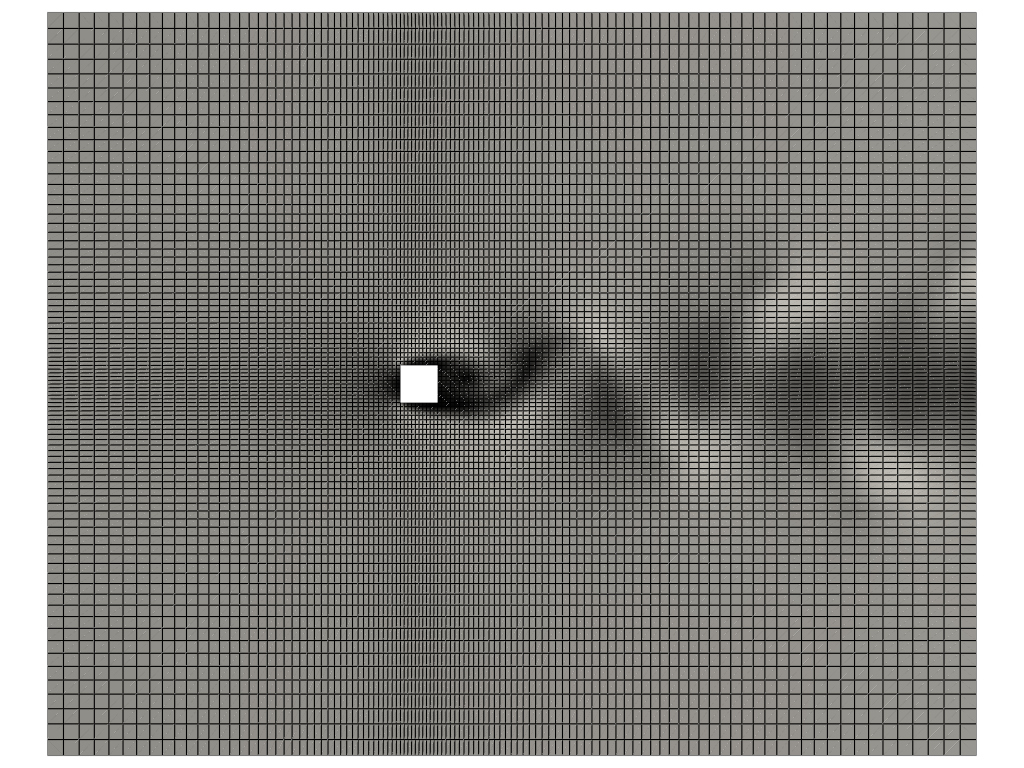

In [ ]:
import pyvista as pv
import numpy as np

file_path = "Data/dragCoeff/fine/icoFoamSolver_13330.vtm"
mesh = pv.read(file_path)

# Combine multiblock
if isinstance(mesh, pv.MultiBlock):
    mesh = mesh.combine()

# Slice
slice_2d = mesh.slice(origin=(0, 0, 0), normal=(0, 0, 1))

# Ensure point data
slice_2d = slice_2d.cell_data_to_point_data()

# Compute velocity magnitude
U = slice_2d["U"]
slice_2d["U_mag"] = np.linalg.norm(U, axis=1)

# Plot
plotter = pv.Plotter()

plotter.add_mesh(
    slice_2d,
    scalars="U_mag",
    cmap="grey",
    show_edges=True,
    edge_color="black",
    line_width=0.5,
    show_scalar_bar=False
)

plotter.view_xy()
plotter.camera.parallel_projection = True
plotter.camera.zoom(1.55)

plotter.show()